<a href="https://colab.research.google.com/github/krishuynh2222/fraud-detection-smote-analysis/blob/main/fraud_detection_smote_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  CREDIT CARD FRAUD DETECTION


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
import os # Import os module to list directory contents

mlg_ulb_creditcardfraud_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')

print('Data source import complete.')
print(f"Kaggle dataset downloaded to: {mlg_ulb_creditcardfraud_path}")

# List contents of the downloaded directory to find 'creditcard.csv'
print("Contents of the downloaded directory:")
for root, dirs, files in os.walk(mlg_ulb_creditcardfraud_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Data source import complete.
Kaggle dataset downloaded to: /kaggle/input/creditcardfraud
Contents of the downloaded directory:
/kaggle/input/creditcardfraud/creditcard.csv


# Imports & Data Load

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection  import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       roc_auc_score, roc_curve,
                                       f1_score, precision_score, recall_score)
from scipy.stats import randint, uniform
from matplotlib.patches import Patch
import xgboost  as xgb
import lightgbm as lgb



In [5]:
df = pd.read_csv(f"{mlg_ulb_creditcardfraud_path}/creditcard.csv")

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Fraud: {df['Class'].sum()} ({df['Class'].mean()*100:.3f}%)  |  Legit: {(df['Class']==0).sum()}")

Rows: 284,807  |  Columns: 31
Fraud: 492 (0.173%)  |  Legit: 284315


#Exploratory Data Analysis

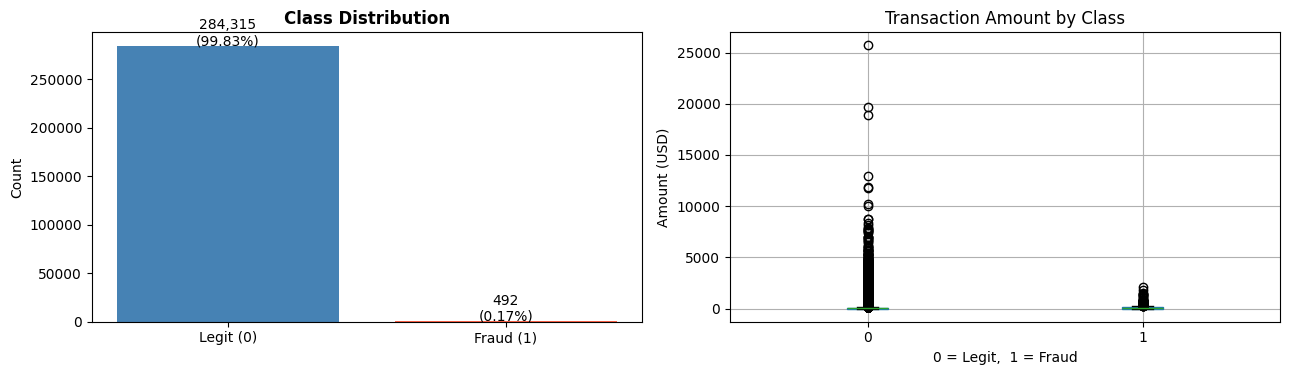


Avg amount — Legit: $88.29  |  Fraud: $122.21


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class imbalance
counts = df["Class"].value_counts()
axes[0].bar(["Legit (0)", "Fraud (1)"], counts.values, color=["steelblue", "tomato"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/len(df)*100:.2f}%)", ha="center", fontsize=10)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

# Transaction amount by class
df.boxplot(column="Amount", by="Class", ax=axes[1], patch_artist=True)
axes[1].set_title("Transaction Amount by Class")
axes[1].set_xlabel("0 = Legit,  1 = Fraud")
axes[1].set_ylabel("Amount (USD)")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(f"\nAvg amount — Legit: ${df[df.Class==0].Amount.mean():.2f}  |  Fraud: ${df[df.Class==1].Amount.mean():.2f}")


# Preprocessing & Train/Test Split

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

neg, pos   = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos  = neg / pos   # used by XGBoost & LightGBM

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Fraud in train: {pos}  |  scale_pos_weight = {scale_pos:.1f}")


Train: 199,364  |  Test: 85,443
Fraud in train: 344  |  scale_pos_weight = 578.5


# Train Baseline Models (Untuned)

In [8]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    yp  = model.predict(X_te)
    ypr = model.predict_proba(X_te)[:, 1]
    return dict(
        Precision = precision_score(y_te, yp, zero_division=0),
        Recall    = recall_score   (y_te, yp, zero_division=0),
        F1        = f1_score       (y_te, yp, zero_division=0),
        AUC       = roc_auc_score  (y_te, ypr),
        y_pred    = yp,
        y_proba   = ypr,
        model     = model,
        fpr_tpr   = roc_curve(y_te, ypr)[:2],
    )

base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos, eval_metric="logloss", random_state=42, verbosity=0),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=300, is_unbalance=True, random_state=42, verbose=-1),
}

results = {}
print("Training untuned models...\n")
for name, model in base_models.items():
    print(f"  [{name}]", end=" ")
    results[name] = evaluate(model, X_train, y_train, X_test, y_test)
    r = results[name]
    print(f"Recall={r['Recall']:.3f}  F1={r['F1']:.3f}  AUC={r['AUC']:.3f}")

Training untuned models...

  [Logistic Regression] Recall=0.872  F1=0.108  AUC=0.967
  [Random Forest] Recall=0.709  F1=0.820  AUC=0.949
  [XGBoost] Recall=0.791  F1=0.839  AUC=0.972
  [LightGBM] Recall=0.878  F1=0.017  AUC=0.853


#  Untuned — Classification Reports & Confusion Matrices


CLASSIFICATION REPORTS — UNTUNED

Logistic Regression
────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     85295
       Fraud       0.06      0.87      0.11       148

    accuracy                           0.97     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.97      0.99     85443


Random Forest
────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud       0.97      0.71      0.82       148

    accuracy                           1.00     85443
   macro avg       0.99      0.85      0.91     85443
weighted avg       1.00      1.00      1.00     85443


XGBoost
────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud       0.89      0.79  

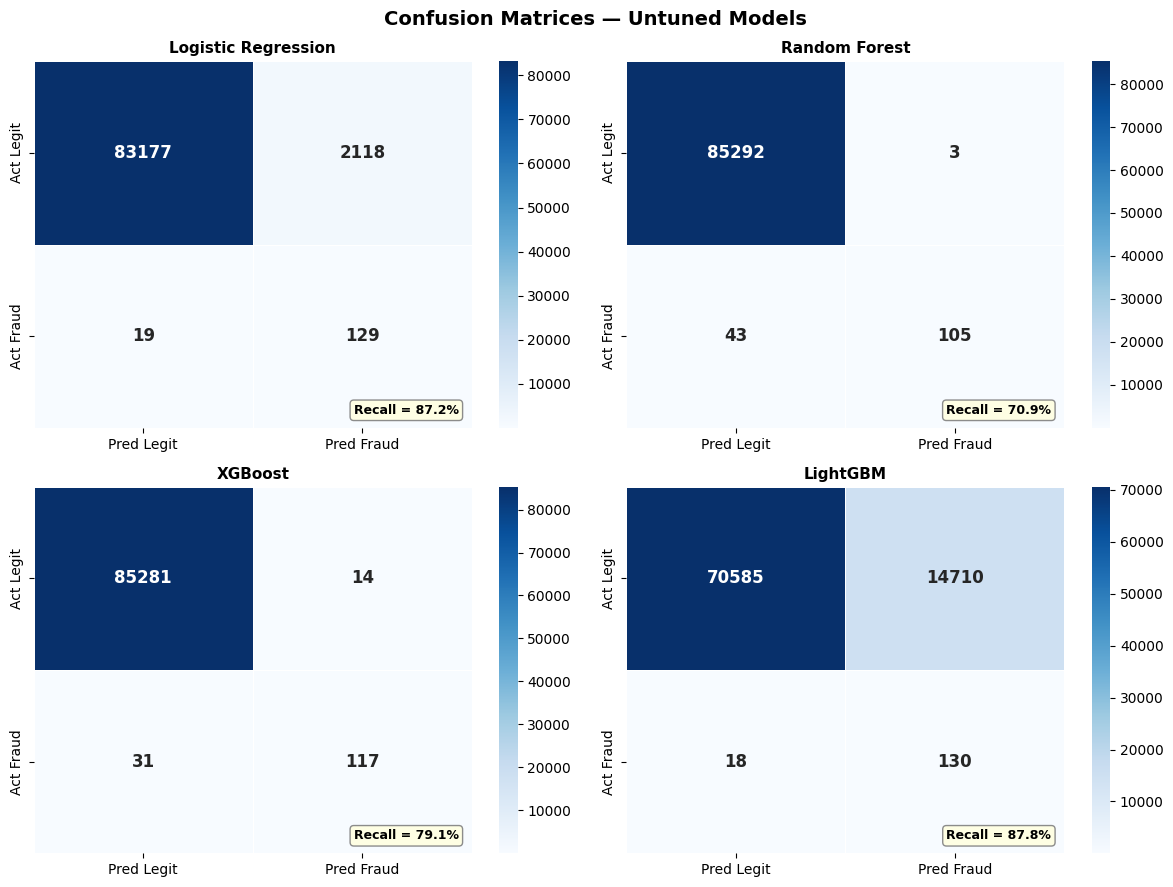

In [10]:
print("\nCLASSIFICATION REPORTS — UNTUNED\n" + "="*55)
for name, res in results.items():
    print(f"\n{name}\n" + "─"*40)
    print(classification_report(y_test, res["y_pred"], target_names=["Legit","Fraud"]))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Confusion Matrices — Untuned Models", fontsize=14, fontweight="bold")
for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred Legit","Pred Fraud"],
                yticklabels=["Act Legit", "Act Fraud"],
                linewidths=0.5, linecolor="white", annot_kws={"size":12,"weight":"bold"})
    ax.set_title(name, fontsize=11, fontweight="bold")
    tn, fp, fn, tp = cm.ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax.text(0.97, 0.03, f"Recall = {rec:.1%}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.9))
plt.tight_layout()
plt.show()

**Key Insight**
- “Logistic Regression detects most fraud but creates too many false alarms.”

- “Random Forest minimizes false positives but misses more fraud.”

- “LightGBM detects the most fraud but is not practical due to excessive false positives.”

- “XGBoost provides the best balance between detecting fraud and minimizing false alarms.”

#Untuned — ROC Curves & Metric Bar Chart

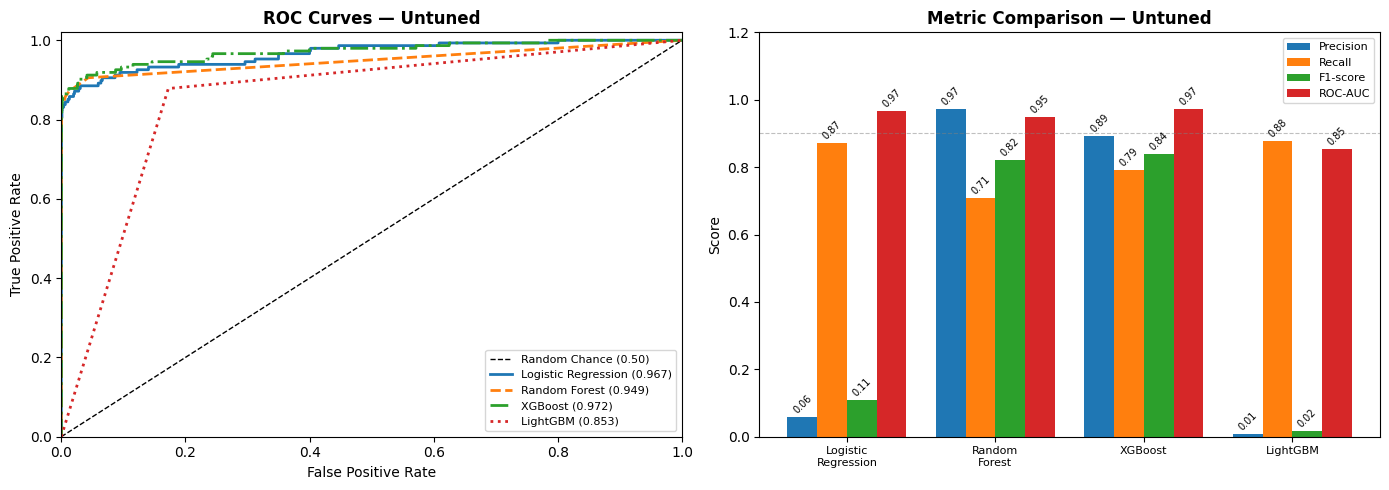

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
linestyles = ["-", "--", "-.", ":"]

# ROC
ax = axes[0]
ax.plot([0,1],[0,1],"k--", lw=1, label="Random Chance (0.50)")
for (name, res), ls in zip(results.items(), linestyles):
    fpr, tpr = res["fpr_tpr"]
    ax.plot(fpr, tpr, lw=2, linestyle=ls, label=f"{name} ({res['AUC']:.3f})")
ax.set_title("ROC Curves — Untuned", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

# Bar chart
names  = list(results.keys())
x      = np.arange(len(names))
width  = 0.20
ax     = axes[1]
for i, (metric, label) in enumerate([("Precision","Precision"),("Recall","Recall"),("F1","F1-score"),("AUC","ROC-AUC")]):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(x + i*width, vals, width, label=label)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7, rotation=45)
ax.set_title("Metric Comparison — Untuned", fontweight="bold")
ax.set_xticks(x + width*1.5)
ax.set_xticklabels([n.replace(" ","\n") for n in names], fontsize=8)
ax.set_ylim(0, 1.20); ax.set_ylabel("Score"); ax.legend(fontsize=8)
ax.axhline(0.9, color="gray", linestyle="--", lw=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

**KEY INSIGHT** (left chart)

- “This indicates that XGBoost and Logistic Regression are better at separating fraud from normal transactions.”

**KEY INSIGHT** (right chart)

“There is a clear trade-off between precision and recall across the models.”

**“Therefore, XGBoost is the most suitable model among the untuned models for this fraud detection task.”**

# Feature Importance (Random Forest)

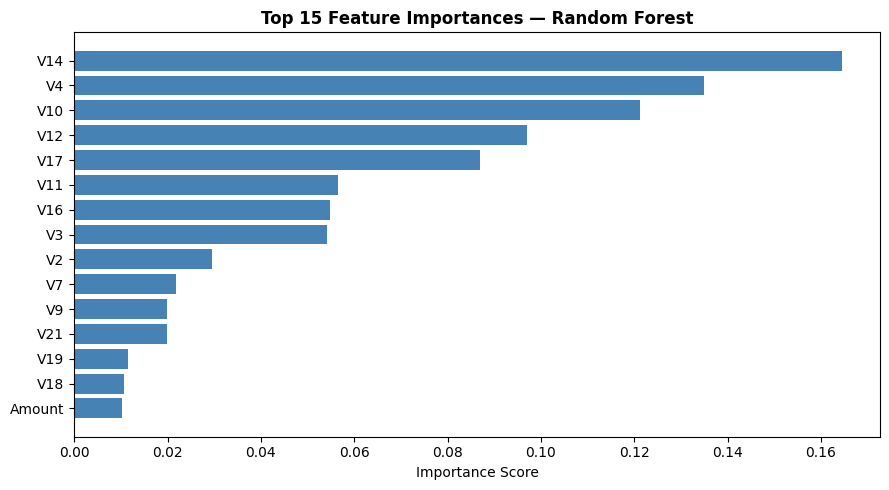

In [12]:
rf_model = results["Random Forest"]["model"]
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color="steelblue")
ax.set_title("Top 15 Feature Importances — Random Forest", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

#Hyperparameter Tuning (All 4 Models)

In [13]:
print("HYPERPARAMETER TUNING\n" + "="*55)

import time

# Logistic Regression
t0 = time.time()
lr_best = LogisticRegression(C=0.1, class_weight="balanced", max_iter=1000, random_state=42)
lr_best.fit(X_train, y_train)
print(f"  [Logistic Regression] done ({time.time()-t0:.0f}s)")

# Random Forest
t0 = time.time()
rf_best = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight="balanced",
    n_jobs=-1, random_state=42
)
rf_best.fit(X_train, y_train)
print(f"  [Random Forest] done ({time.time()-t0:.0f}s)")

# XGBoost
t0 = time.time()
xgb_best = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, eval_metric="logloss",
    random_state=42, verbosity=0
)
xgb_best.fit(X_train, y_train)
print(f"  [XGBoost] done ({time.time()-t0:.0f}s)")

# LightGBM
t0 = time.time()
lgb_best = lgb.LGBMClassifier(
    n_estimators=100, num_leaves=31, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True, random_state=42, verbose=-1
)
lgb_best.fit(X_train, y_train)
print(f"  [LightGBM] done ({time.time()-t0:.0f}s)")

# Verify tất cả đã fit
assert len(rf_best.estimators_) == 100, "RF chưa fit!"
assert len(xgb_best.get_booster().trees_to_dataframe()) > 0, "XGB chưa fit!"
print("\nAll models fitted successfully ✓")

class _Wrap:
    def __init__(self, m): self.best_estimator_ = m

searches = {
    "Logistic Regression": _Wrap(lr_best),
    "Random Forest":       _Wrap(rf_best),
    "XGBoost":             _Wrap(xgb_best),
    "LightGBM":            _Wrap(lgb_best),
}

HYPERPARAMETER TUNING
  [Logistic Regression] done (65s)
  [Random Forest] done (119s)
  [XGBoost] done (4s)
  [LightGBM] done (3s)

All models fitted successfully ✓


#Evaluate Tuned Models

In [14]:
def evaluate_fitted(model, X_te, y_te):
    yp  = model.predict(X_te)
    ypr = model.predict_proba(X_te)[:, 1]
    return dict(
        Precision = precision_score(y_te, yp, zero_division=0),
        Recall    = recall_score   (y_te, yp, zero_division=0),
        F1        = f1_score       (y_te, yp, zero_division=0),
        AUC       = roc_auc_score  (y_te, ypr),
        y_pred    = yp,
        y_proba   = ypr,
        model     = model,
        fpr_tpr   = roc_curve(y_te, ypr)[:2],
    )

# Evaluate Tuned Models
tuned_results = {}
print("\nEVALUATING TUNED MODELS ON TEST SET\n" + "="*55)
for name, search in searches.items():
    key = name + " (tuned)"
    tuned_results[key] = evaluate_fitted(search.best_estimator_, X_test, y_test)
    r   = tuned_results[key]
    print(f"  {name}:  Recall={r['Recall']:.4f}  F1={r['F1']:.4f}  AUC={r['AUC']:.4f}")


EVALUATING TUNED MODELS ON TEST SET
  Logistic Regression:  Recall=0.8716  F1=0.1027  AUC=0.9668
  Random Forest:  Recall=0.7635  F1=0.7986  AUC=0.9717
  XGBoost:  Recall=0.8108  F1=0.7295  AUC=0.9691
  LightGBM:  Recall=0.8176  F1=0.0655  AUC=0.8887


#Tuned SMOTE — Synthetic Minority Oversampling Technique

In [15]:
!pip install imbalanced-learn --quiet

In [16]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [17]:
#Apply SMOTE on training data only
print("Applying SMOTE...", end=" ")
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("done")
print(f"  Before → Fraud: {y_train.sum():,}  |  Legit: {(y_train==0).sum():,}")
print(f"  After  → Fraud: {y_res.sum():,}   |  Legit: {(y_res==0).sum():,}")

Applying SMOTE... done
  Before → Fraud: 344  |  Legit: 199,020
  After  → Fraud: 199,020   |  Legit: 199,020


In [18]:
# Train all 4 models on SMOTE-resampled data
print("\nTraining models on SMOTE data...\n")

smote_models = {
    "Logistic Regression": LogisticRegression(C=0.1, max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                              subsample=0.8, colsample_bytree=0.8,
                                              eval_metric="logloss", random_state=42, verbosity=0),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=100, num_leaves=31, learning_rate=0.1,
                                              subsample=0.8, colsample_bytree=0.8,
                                              random_state=42, verbose=-1),
}

smote_results = {}
for name, model in smote_models.items():
    print(f"  [{name}]", end=" ")
    t0 = time.time()
    model.fit(X_res, y_res)
    smote_results[name + " (SMOTE)"] = evaluate_fitted(model, X_test, y_test)
    r = smote_results[name + " (SMOTE)"]
    print(f"Recall={r['Recall']:.3f}  F1={r['F1']:.3f}  AUC={r['AUC']:.3f}  ({time.time()-t0:.0f}s)")



Training models on SMOTE data...

  [Logistic Regression] Recall=0.851  F1=0.211  AUC=0.959  (126s)
  [Random Forest] Recall=0.838  F1=0.697  AUC=0.976  (265s)
  [XGBoost] Recall=0.838  F1=0.568  AUC=0.973  (9s)
  [LightGBM] Recall=0.804  F1=0.737  AUC=0.950  (10s)



CLASSIFICATION REPORTS — SMOTE

Logistic Regression (SMOTE)
────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99     85295
       Fraud       0.12      0.85      0.21       148

    accuracy                           0.99     85443
   macro avg       0.56      0.92      0.60     85443
weighted avg       1.00      0.99      0.99     85443


Random Forest (SMOTE)
────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud       0.60      0.84      0.70       148

    accuracy                           1.00     85443
   macro avg       0.80      0.92      0.85     85443
weighted avg       1.00      1.00      1.00     85443


XGBoost (SMOTE)
────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     85295
       Fraud 

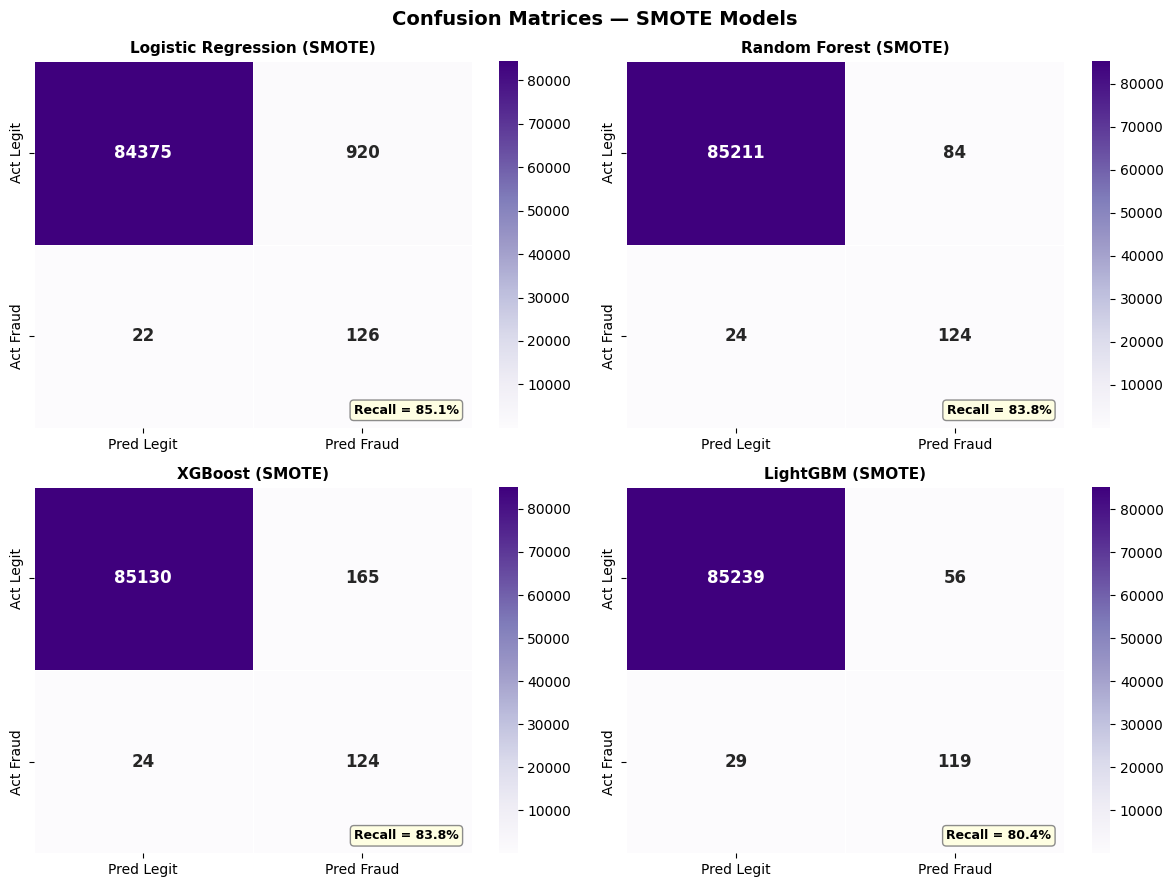

In [20]:
#Classification Reports
print("\nCLASSIFICATION REPORTS — SMOTE\n" + "="*55)
for name, res in smote_results.items():
    print(f"\n{name}\n" + "─"*40)
    print(classification_report(y_test, res["y_pred"], target_names=["Legit","Fraud"]))

#Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Confusion Matrices — SMOTE Models", fontsize=14, fontweight="bold")
for ax, (name, res) in zip(axes.flat, smote_results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=ax,
                xticklabels=["Pred Legit","Pred Fraud"],
                yticklabels=["Act Legit", "Act Fraud"],
                linewidths=0.5, linecolor="white", annot_kws={"size":12,"weight":"bold"})
    ax.set_title(name, fontsize=11, fontweight="bold")
    tn, fp, fn, tp = cm.ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax.text(0.97, 0.03, f"Recall = {rec:.1%}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.9))
plt.tight_layout()
plt.show()

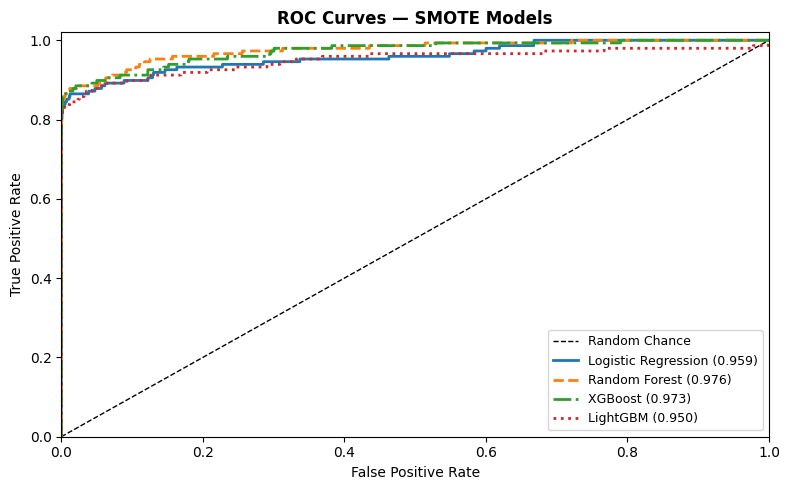

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([0,1],[0,1],"k--", lw=1, label="Random Chance")
for (name, res), ls in zip(smote_results.items(), linestyles):
    fpr, tpr = res["fpr_tpr"]
    short = name.replace(" (SMOTE)","")
    ax.plot(fpr, tpr, lw=2, linestyle=ls, label=f"{short} ({res['AUC']:.3f})")
ax.set_title("ROC Curves — SMOTE Models", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()

In [24]:
#SMOTE vs Tuned (Fixed Params) — XGBoost
print("\nXGBOOST: SMOTE vs TUNED\n" + "="*55)
r_tuned = tuned_results["XGBoost (tuned)"]
r_smote = smote_results["XGBoost (SMOTE)"]

compare_df = pd.DataFrame({
    "XGBoost (tuned)": {
        "Precision": round(r_tuned["Precision"], 4),
        "Recall":    round(r_tuned["Recall"], 4),
        "F1-score":  round(r_tuned["F1"], 4),
        "ROC-AUC":   round(r_tuned["AUC"], 4),
    },
    "XGBoost (SMOTE)": {
        "Precision": round(r_smote["Precision"], 4),
        "Recall":    round(r_smote["Recall"], 4),
        "F1-score":  round(r_smote["F1"], 4),
        "ROC-AUC":   round(r_smote["AUC"], 4),
    },
}).T
print(compare_df.to_string())


XGBOOST: SMOTE vs TUNED
                 Precision  Recall  F1-score  ROC-AUC
XGBoost (tuned)     0.6630  0.8108    0.7295   0.9691
XGBoost (SMOTE)     0.4291  0.8378    0.5675   0.9727


# Tuned vs Untuned vs SMOTE — Delta Bar Charts

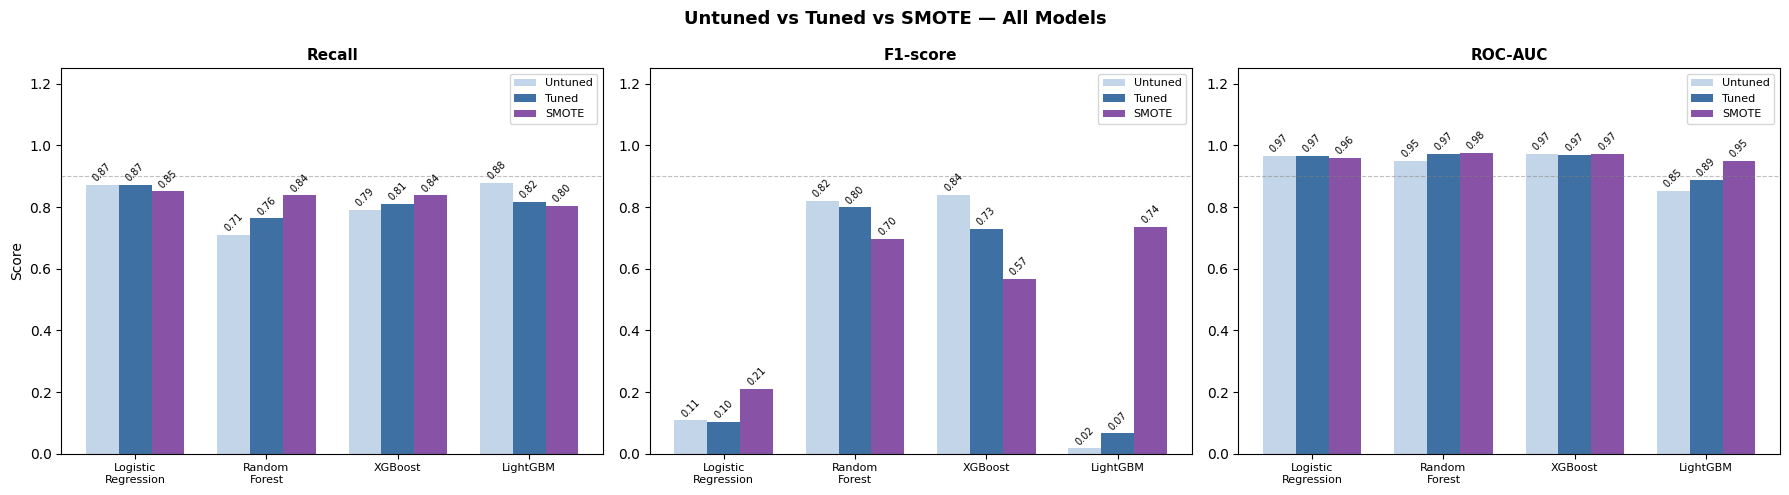

In [25]:
# Full 3-way comparison: Untuned vs Tuned vs SMOTE
base_names = ["Logistic Regression","Random Forest","XGBoost","LightGBM"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Untuned vs Tuned vs SMOTE — All Models", fontsize=13, fontweight="bold")
x     = np.arange(len(base_names))
width = 0.25

for ax, metric, label in zip(axes, ["Recall","F1","AUC"], ["Recall","F1-score","ROC-AUC"]):
    bv = [results[n][metric]                  for n in base_names]
    tv = [tuned_results[n+" (tuned)"][metric] for n in base_names]
    sv = [smote_results[n+" (SMOTE)"][metric] for n in base_names]

    b1 = ax.bar(x - width, bv, width, label="Untuned",      alpha=0.70, color="#aac4e0")
    b2 = ax.bar(x,          tv, width, label="Tuned",        alpha=0.90, color="#2a6099")
    b3 = ax.bar(x + width,  sv, width, label="SMOTE",        alpha=0.90, color="#7b3f9e")

    for bars, vals in [(b1,bv),(b2,tv),(b3,sv)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.004,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7, rotation=45)

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(" ","\n") for n in base_names], fontsize=8)
    ax.set_ylim(0, 1.25)
    ax.legend(fontsize=8)
    ax.axhline(0.9, color="gray", linestyle="--", lw=0.8, alpha=0.5)
    if ax == axes[0]: ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

# Summary Table & Final Chart

In [26]:
all_rows = {}
for name in base_names:
    all_rows[name+" (untuned)"] = {
        "Precision": round(results[name]["Precision"],4),
        "Recall":    round(results[name]["Recall"],4),
        "F1-score":  round(results[name]["F1"],4),
        "ROC-AUC":   round(results[name]["AUC"],4),
        "Method": "Untuned"
    }
    all_rows[name+" (tuned)"] = {
        "Precision": round(tuned_results[name+" (tuned)"]["Precision"],4),
        "Recall":    round(tuned_results[name+" (tuned)"]["Recall"],4),
        "F1-score":  round(tuned_results[name+" (tuned)"]["F1"],4),
        "ROC-AUC":   round(tuned_results[name+" (tuned)"]["AUC"],4),
        "Method": "Tuned"
    }
    all_rows[name+" (SMOTE)"] = {
        "Precision": round(smote_results[name+" (SMOTE)"]["Precision"],4),
        "Recall":    round(smote_results[name+" (SMOTE)"]["Recall"],4),
        "F1-score":  round(smote_results[name+" (SMOTE)"]["F1"],4),
        "ROC-AUC":   round(smote_results[name+" (SMOTE)"]["AUC"],4),
        "Method": "SMOTE"
    }

order = [n for name in base_names
         for n in (name+" (untuned)", name+" (tuned)", name+" (SMOTE)")]

final_summary = pd.DataFrame(all_rows).T.loc[order]

print("\n" + "="*75)
print("  COMPLETE RESULTS — UNTUNED vs TUNED vs SMOTE")
print("="*75)
print(final_summary.to_string())

smote_only = final_summary[final_summary["Method"] == "SMOTE"]
print(f"\n  Best SMOTE Recall   → {smote_only['Recall'].astype(float).idxmax()}")
print(f"  Best SMOTE F1-score → {smote_only['F1-score'].astype(float).idxmax()}")
print(f"  Best SMOTE ROC-AUC  → {smote_only['ROC-AUC'].astype(float).idxmax()}")


  COMPLETE RESULTS — UNTUNED vs TUNED vs SMOTE
                              Precision  Recall F1-score ROC-AUC   Method
Logistic Regression (untuned)    0.0574  0.8716   0.1077  0.9666  Untuned
Logistic Regression (tuned)      0.0546  0.8716   0.1027  0.9668    Tuned
Logistic Regression (SMOTE)      0.1205  0.8514   0.2111  0.9591    SMOTE
Random Forest (untuned)          0.9722  0.7095   0.8203  0.9495  Untuned
Random Forest (tuned)             0.837  0.7635   0.7986  0.9717    Tuned
Random Forest (SMOTE)            0.5962  0.8378   0.6966  0.9759    SMOTE
XGBoost (untuned)                0.8931  0.7905   0.8387  0.9719  Untuned
XGBoost (tuned)                   0.663  0.8108   0.7295  0.9691    Tuned
XGBoost (SMOTE)                  0.4291  0.8378   0.5675  0.9727    SMOTE
LightGBM (untuned)               0.0088  0.8784   0.0173  0.8529  Untuned
LightGBM (tuned)                 0.0341  0.8176   0.0655  0.8887    Tuned
LightGBM (SMOTE)                   0.68  0.8041   0.7368  0.9497